# Input-Output Space Mapping: CSTR Design

This notebook demonstrates GMM and Flow Matching approaches for bidirectional space mapping.

**Problem:** Map desired exit concentrations (C_a, C_b) to reactor design parameters (R, RT) for a CSTR with competing reactions.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.13.5 (main, Jun 11 2025, 15:36:57) [Clang 17.0.0 (clang-1700.0.13.3)]
Platform: macOS-26.5.2-arm64-arm-64bit-Mach-O
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.5
scipy                1.16.3
matplotlib           3.10.8


sklearn              1.8.0


torch                2.9.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2026-08-23 10:59:06
Initial memory usage: 303.58 MB


## System Information

This section documents the computational environment used to run this notebook.

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch

# Import reusable utilities
from generative_optimization import (
    generate_samples,
    best_gmm,
    ConditionalFlowMatching
)

# Figure settings for publication
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10

warnings.filterwarnings('ignore')

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete")

Setup complete


---
## Problem: CSTR Design with Competing Reactions

Consider a continuous stirred tank reactor (CSTR) with two competing reactions that both consume $A$:
$$A \xrightarrow{k_1} B \quad (r_1 = k_1 C_a^2), \qquad A \xrightarrow{k_2} C \quad (r_2 = k_2 C_a)$$

$B$ is the desired product and $C$ is an undesired byproduct. The net species rates are
$r_A = -(k_1 C_a^2 + k_2 C_a)$ and $r_B = k_1 C_a^2$, since $B$ is not consumed by either reaction.

**Design parameters:**
- $R$: reactor radius (determines volume $V = \pi R^2 H$)
- $RT$: dimensionless temperature parameter (affects rate constants)

**Rate constants:**
$$k_1 = e^{-3/RT}, \quad k_2 = e^{-10/RT}$$

**Steady-state concentrations:**

From material balances:
$$C_a = \frac{-b + \sqrt{b^2 - 4ac}}{2a}, \quad C_b = \frac{k_1 C_a^2 V}{v_0}$$

where $a = V k_1$, $b = v_0 + V k_2$, $c = -v_0 C_{a0}$

**Forward problem:** Given $(R, RT)$ → compute $(C_a, C_b)$

**Inverse problem:** Given desired $(C_a, C_b)$ → find $(R, RT)$

**Reactor parameters:**
- Height: $H = 1$ m
- Volumetric flow rate: $v_0 = 1$ m³/s
- Inlet concentration: $C_{a0} = 1$ mol/L

In [3]:
# CSTR model parameters
H = 1     # height (m)
vo = 1    # volumetric flow rate (m³/s)
Cao = 1   # inlet concentration (mol/L)

def compute_concentrations(R, RT):
    """Compute exit concentrations given design parameters."""
    V = np.pi * R**2 * H
    k1 = np.exp(-3 / RT)
    k2 = np.exp(-10 / RT)
    
    # Quadratic solution for Ca
    a = V * k1
    b = vo + V * k2
    c = -vo * Cao
    Ca = (-b + np.sqrt(b**2 - 4 * a * c)) / (2 * a)
    
    # Compute Cb
    Cb = k1 * Ca**2 * V / vo
    
    return Ca, Cb

# Test the forward model
R_test, RT_test = 1.5, 5.0
Ca_test, Cb_test = compute_concentrations(R_test, RT_test)
print(f"Test: R={R_test}, RT={RT_test}")
print(f"  → Ca={Ca_test:.4f}, Cb={Cb_test:.4f}")

Test: R=1.5, RT=5.0
  → Ca=0.3147, Cb=0.3842


### Generate Training Data

In [4]:
# Sample design parameter space
bounds = [[0.1, 3], [0.1, 15]]  # [R, RT]
X = generate_samples(bounds, n_samples=1024, seed=42)

R, RT = X.T
Ca, Cb = compute_concentrations(R, RT)

# Build joint dataset: [R, RT, Ca, Cb]
data = np.column_stack([R, RT, Ca, Cb])

print(f"Training data shape: {data.shape}")
print(f"Columns: [R, RT, Ca, Cb]")
print(f"\nDesign parameters:")
print(f"  R range:  [{R.min():.2f}, {R.max():.2f}] m")
print(f"  RT range: [{RT.min():.2f}, {RT.max():.2f}]")
print(f"\nExit concentrations:")
print(f"  Ca range: [{Ca.min():.3f}, {Ca.max():.3f}] mol/L")
print(f"  Cb range: [{Cb.min():.3f}, {Cb.max():.3f}] mol/L")

Training data shape: (1024, 4)
Columns: [R, RT, Ca, Cb]

Design parameters:
  R range:  [0.10, 3.00] m
  RT range: [0.11, 15.00]

Exit concentrations:
  Ca range: [0.061, 1.000] mol/L
  Cb range: [0.000, 0.623] mol/L


### Visualize Input-Output Relationship

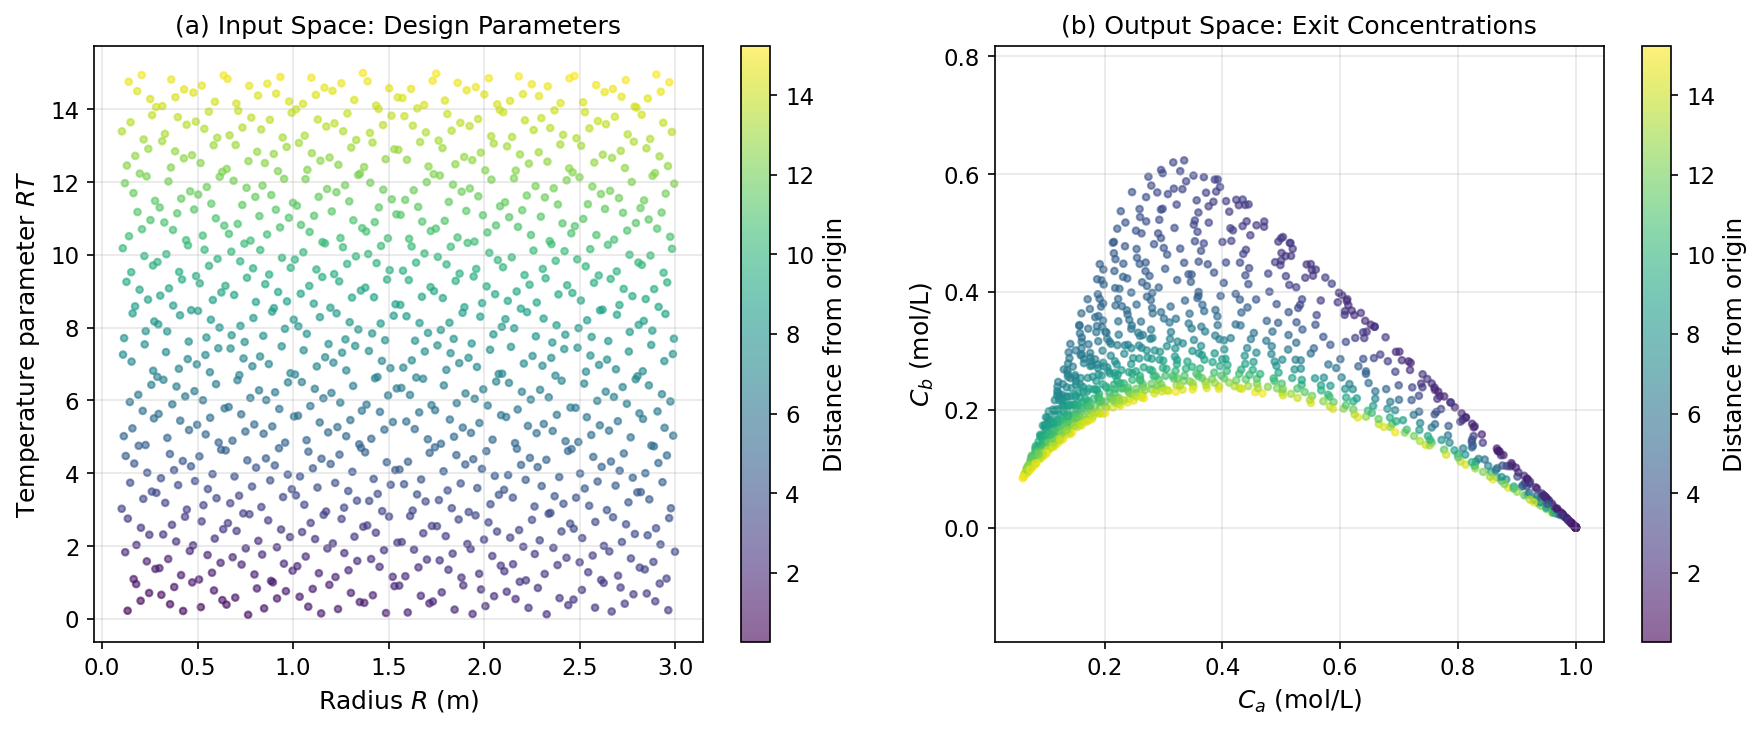


The forward mapping from (R, RT) → (Ca, Cb) is many-to-one:
different design parameters can produce similar concentrations.


In [5]:
# Visualize the input-output mapping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Color by distance from origin in design space
colors = np.sqrt(R**2 + RT**2)

# Left: Input space (design parameters)
sc1 = axes[0].scatter(R, RT, s=10, c=colors, cmap='viridis', alpha=0.6)
axes[0].set_xlabel('Radius $R$ (m)')
axes[0].set_ylabel('Temperature parameter $RT$')
axes[0].set_title('(a) Input Space: Design Parameters')
axes[0].grid(True, alpha=0.3)
plt.colorbar(sc1, ax=axes[0], label='Distance from origin')

# Right: Output space (concentrations)
sc2 = axes[1].scatter(Ca, Cb, s=10, c=colors, cmap='viridis', alpha=0.6)
axes[1].set_xlabel('$C_a$ (mol/L)')
axes[1].set_ylabel('$C_b$ (mol/L)')
axes[1].set_title('(b) Output Space: Exit Concentrations')
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')
plt.colorbar(sc2, ax=axes[1], label='Distance from origin')

plt.tight_layout()
plt.show()

print("\nThe forward mapping from (R, RT) → (Ca, Cb) is many-to-one:")
print("different design parameters can produce similar concentrations.")

### Train GMM for Space Mapping

In [6]:
# Build GMM on joint distribution [R, RT, Ca, Cb]
gmm, gmm_info = best_gmm(data, verbose=True)
print(f"\nBest GMM: {gmm_info['best_k']} components")

k=1: BIC=5415.0 *
k=2: BIC=3112.9 *
k=3: BIC=928.9 *
k=4: BIC=-1298.8 *
k=5: BIC=-2154.3 *


k=6: BIC=-3214.1 *
k=7: BIC=-3715.5 *
k=8: BIC=-4060.5 *


k=9: BIC=-4538.6 *
k=10: BIC=-5048.9 *
k=11: BIC=-5431.3 *


k=12: BIC=-5578.5 *
k=13: BIC=-5773.9 *


k=14: BIC=-5944.3 *
k=15: BIC=-6064.2 *


...

k=36: BIC=-7377.8


k=37: BIC=-7368.6


k=38: BIC=-7269.7


k=39: BIC=-7307.6


k=40: BIC=-7211.0
Early stopping at k=40

Best GMM: 30 components


### Train Flow Matching for Space Mapping

In [7]:
# Train Flow Matching: generate [R, RT] conditioned on [Ca, Cb]
x_data = data[:, :2]  # R, RT
c_data = data[:, 2:]  # Ca, Cb

fm_map = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=128, n_layers=4)
fm_history = fm_map.fit(x_data, c_data, epochs=1000, batch_size=64, verbose=True)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

### Map Desired Output Region to Input Space

**Design goal:** Find reactor designs that produce concentrations in a target region:
- Center: $(C_a, C_b) = (0.58, 0.30)$ mol/L
- Radius: $0.08$ mol/L

In [8]:
# Define desired output region (circular region in concentration space)
center = (0.58, 0.3)
radius = 0.08

print(f"Target concentration region:")
print(f"  Center: Ca={center[0]}, Cb={center[1]} mol/L")
print(f"  Radius: {radius} mol/L")
print(f"\nGoal: Find all (R, RT) designs that produce concentrations in this region")

Target concentration region:
  Center: Ca=0.58, Cb=0.3 mol/L
  Radius: 0.08 mol/L

Goal: Find all (R, RT) designs that produce concentrations in this region


In [9]:
# GMM: Map desired output region to input space
# Generate grid of points in desired circle
x1 = np.linspace(center[0] - radius, center[0] + radius, 100)
x2 = np.linspace(center[1] - radius, center[1] + radius, 100)
X1, X2 = np.meshgrid(x1, x2)
X1_flat = X1.flatten()
X2_flat = X2.flatten()

# Filter to points inside circle
ind = (X1_flat - center[0])**2 + (X2_flat - center[1])**2 <= radius**2
Ca_grid = X1_flat[ind]
Cb_grid = X2_flat[ind]

# Predict input space (R, RT) from output space (Ca, Cb)
pred_gmm = gmm.predict([2, 3], np.column_stack([Ca_grid, Cb_grid]))
R_gmm, RT_gmm = pred_gmm.T

print(f"GMM: Mapped {len(R_gmm)} points from output to input space")
print(f"  R range:  [{R_gmm.min():.2f}, {R_gmm.max():.2f}] m")
print(f"  RT range: [{RT_gmm.min():.2f}, {RT_gmm.max():.2f}]")

GMM: Mapped 7668 points from output to input space
  R range:  [0.50, 1.37] m
  RT range: [1.75, 11.47]


In [10]:
# Flow Matching: Map desired output region to input space
# Sample points uniformly in the circular region
n_samples = 500
theta = np.random.uniform(0, 2*np.pi, n_samples)
r = np.sqrt(np.random.uniform(0, 1, n_samples)) * radius
Ca_fm_target = center[0] + r * np.cos(theta)
Cb_fm_target = center[1] + r * np.sin(theta)

# Map to input space
c_values = np.column_stack([Ca_fm_target, Cb_fm_target])
mapped_fm = []
for c in c_values:
    s = fm_map.sample(c_values=[c], n_samples=1, n_steps=100)
    mapped_fm.append(s[0])
mapped_fm = np.array(mapped_fm)
R_fm, RT_fm = mapped_fm.T

print(f"Flow Matching: Mapped {len(R_fm)} points from output to input space")
print(f"  R range:  [{R_fm.min():.2f}, {R_fm.max():.2f}] m")
print(f"  RT range: [{RT_fm.min():.2f}, {RT_fm.max():.2f}]")

Flow Matching: Mapped 500 points from output to input space
  R range:  [0.51, 1.15] m
  RT range: [1.76, 11.15]


---
## Publication Figure: GMM vs Flow Matching Space Mapping

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


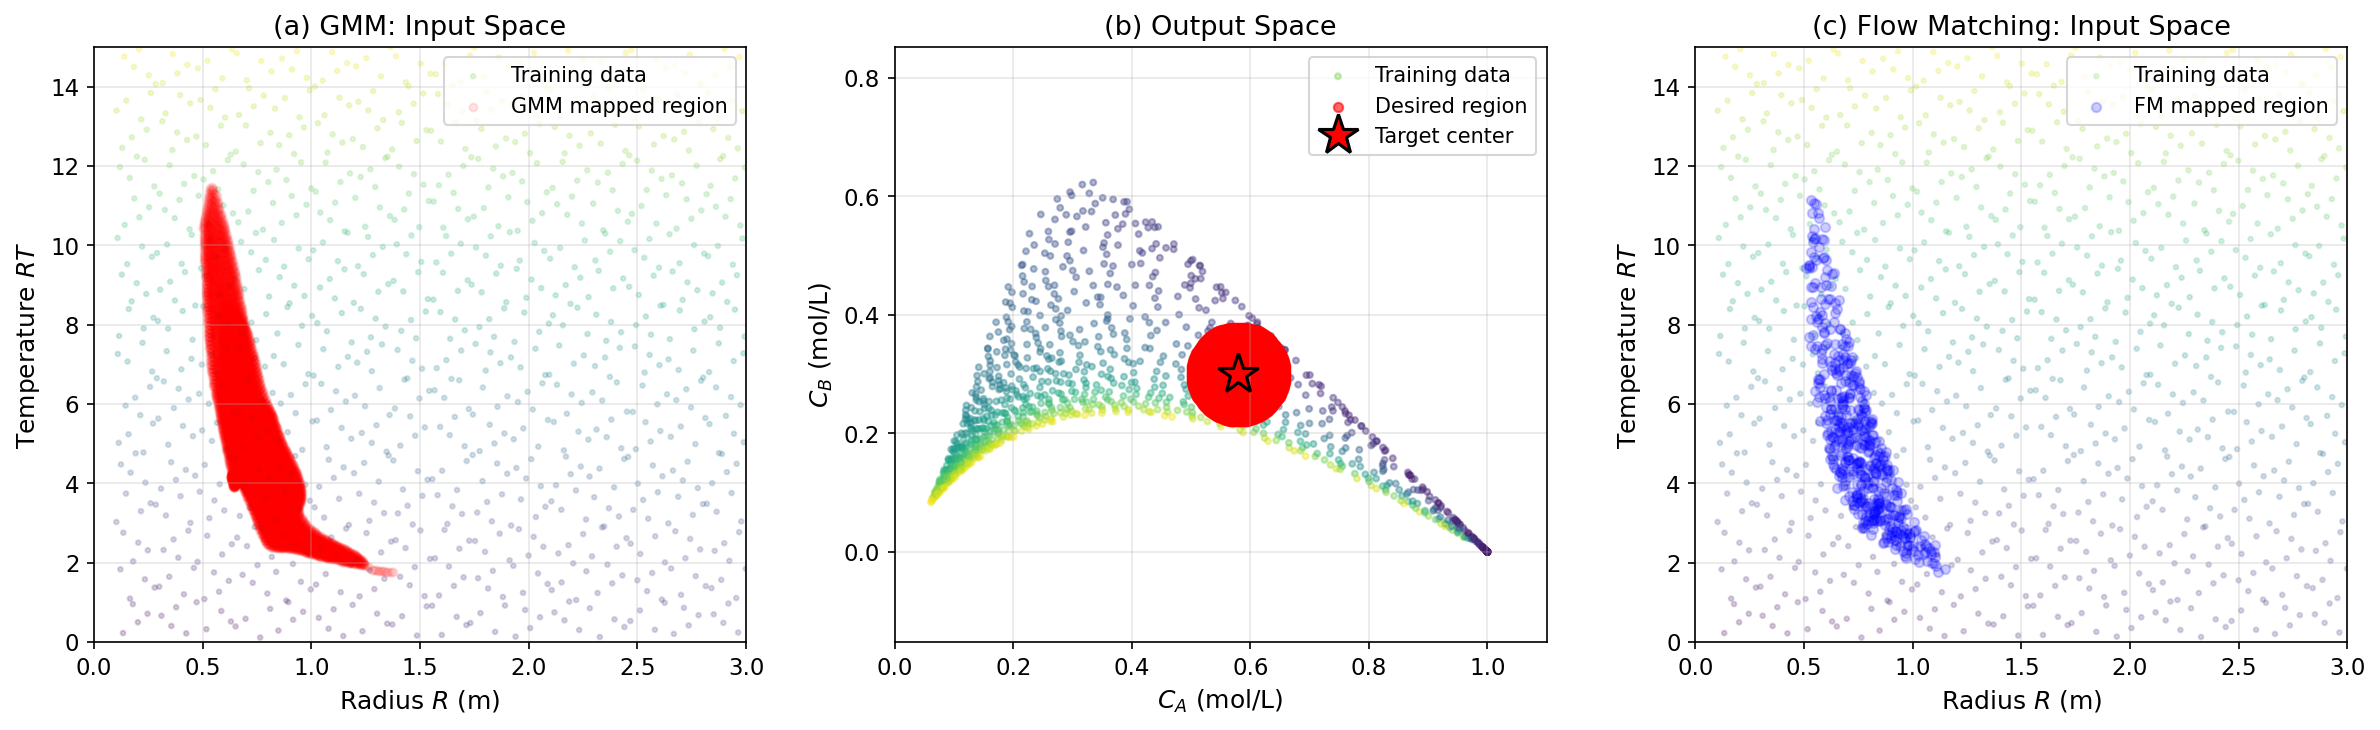


Figure saved as 'space_mapping_comparison.png'

Layout:
  (a) Left:   GMM maps desired concentrations → design parameters (R, RT)
  (b) Middle: Desired concentration region in output space
  (c) Right:  Flow Matching maps desired concentrations → design parameters (R, RT)


In [11]:
# Create publication figure: 3-panel layout
# Left: GMM mapping to input space
# Middle: Output space with desired region
# Right: Flow Matching mapping to input space

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Color scheme for background training data
colors = np.sqrt(R**2 + RT**2)

# ============================================================
# Left: GMM mapping to input space
# ============================================================
ax = axes[0]
ax.scatter(R, RT, s=5, c=colors, cmap='viridis', alpha=0.2, label='Training data')
ax.scatter(R_gmm, RT_gmm, s=15, c='red', alpha=0.1, label='GMM mapped region')
ax.set_xlabel('Radius $R$ (m)', fontsize=12)
ax.set_ylabel('Temperature $RT$', fontsize=12)
ax.set_title('(a) GMM: Input Space', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 3)
ax.set_ylim(0, 15)

# ============================================================
# Middle: Output space with desired region
# ============================================================
ax = axes[1]
ax.scatter(Ca, Cb, s=8, c=colors, cmap='viridis', alpha=0.4, label='Training data')
ax.scatter(Ca_grid, Cb_grid, c='red', s=20, alpha=0.6, label='Desired region')
circle = plt.Circle(center, radius, fill=False, color='red', linestyle='--', linewidth=2.5)
ax.add_patch(circle)
ax.plot(center[0], center[1], 'r*', ms=20, markeredgecolor='black', 
        markeredgewidth=1.5, label='Target center', zorder=10)
ax.set_xlabel('$C_A$ (mol/L)', fontsize=12)
ax.set_ylabel('$C_B$ (mol/L)', fontsize=12)
ax.set_title('(b) Output Space', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 0.7)

# ============================================================
# Right: Flow Matching mapping to input space
# ============================================================
ax = axes[2]
ax.scatter(R, RT, s=5, c=colors, cmap='viridis', alpha=0.2, label='Training data')
ax.scatter(R_fm, RT_fm, c='blue', s=20, alpha=0.2, label='FM mapped region')
ax.set_xlabel('Radius $R$ (m)', fontsize=12)
ax.set_ylabel('Temperature $RT$', fontsize=12)
ax.set_title('(c) Flow Matching: Input Space', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 3)
ax.set_ylim(0, 15)

plt.tight_layout()
plt.savefig('space_mapping_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'space_mapping_comparison.png'")
print("\nLayout:")
print("  (a) Left:   GMM maps desired concentrations → design parameters (R, RT)")
print("  (b) Middle: Desired concentration region in output space")
print("  (c) Right:  Flow Matching maps desired concentrations → design parameters (R, RT)")

### Validation: Forward Model Check

Verify that the mapped design parameters actually produce concentrations in the target region.

In [12]:
# Validate GMM mapping: compute concentrations from mapped designs
Ca_gmm_check, Cb_gmm_check = compute_concentrations(R_gmm, RT_gmm)

# Check if they fall in desired region
dist_gmm = np.sqrt((Ca_gmm_check - center[0])**2 + (Cb_gmm_check - center[1])**2)
in_region_gmm = dist_gmm <= radius

print("GMM Validation:")
print(f"  Mapped {len(R_gmm)} designs")
print(f"  {in_region_gmm.sum()} ({100*in_region_gmm.mean():.1f}%) produce concentrations in target region")
print(f"  Mean distance from target center: {dist_gmm.mean():.4f} mol/L")
print(f"  Max distance from target center:  {dist_gmm.max():.4f} mol/L")

# Validate Flow Matching mapping
Ca_fm_check, Cb_fm_check = compute_concentrations(R_fm, RT_fm)

dist_fm = np.sqrt((Ca_fm_check - center[0])**2 + (Cb_fm_check - center[1])**2)
in_region_fm = dist_fm <= radius

print(f"\nFlow Matching Validation:")
print(f"  Mapped {len(R_fm)} designs")
print(f"  {in_region_fm.sum()} ({100*in_region_fm.mean():.1f}%) produce concentrations in target region")
print(f"  Mean distance from target center: {dist_fm.mean():.4f} mol/L")
print(f"  Max distance from target center:  {dist_fm.max():.4f} mol/L")

GMM Validation:
  Mapped 7668 designs
  7066 (92.1%) produce concentrations in target region
  Mean distance from target center: 0.0543 mol/L
  Max distance from target center:  0.1150 mol/L

Flow Matching Validation:
  Mapped 500 designs
  482 (96.4%) produce concentrations in target region
  Mean distance from target center: 0.0523 mol/L
  Max distance from target center:  0.0926 mol/L


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


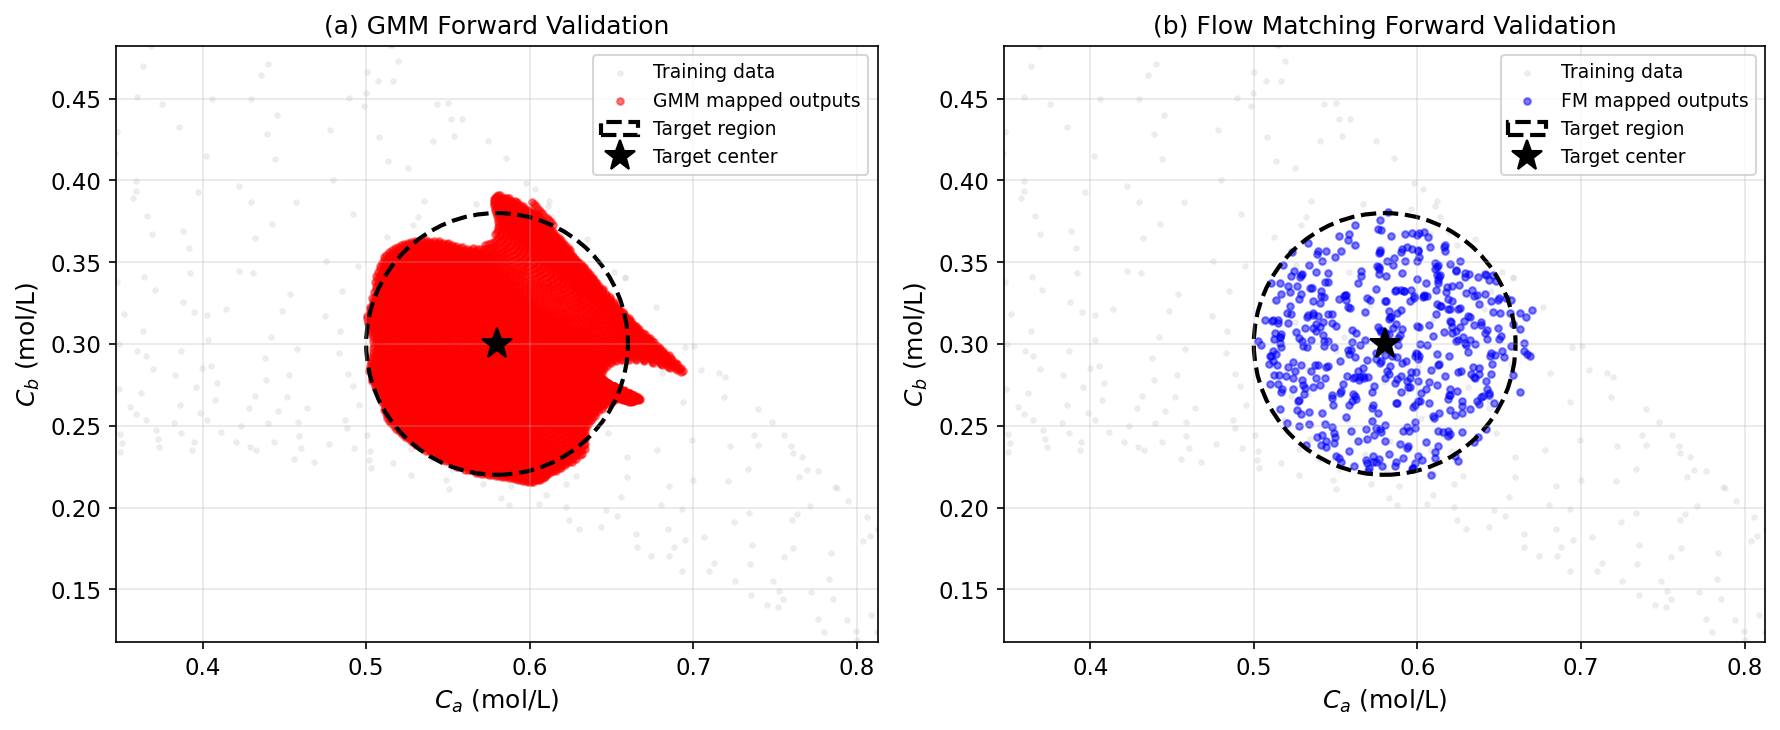


Both methods successfully map the desired output region to viable design parameters.


In [13]:
# Visualize validation: show where the mapped designs actually land
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# GMM validation
ax = axes[0]
ax.scatter(Ca, Cb, s=5, c='lightgray', alpha=0.3, label='Training data')
ax.scatter(Ca_gmm_check, Cb_gmm_check, s=10, c='red', alpha=0.5, label='GMM mapped outputs')
circle = plt.Circle(center, radius, fill=False, color='black', linestyle='--', linewidth=2, label='Target region')
ax.add_patch(circle)
ax.plot(center[0], center[1], 'k*', ms=15, label='Target center')
ax.set_xlabel('$C_a$ (mol/L)')
ax.set_ylabel('$C_b$ (mol/L)')
ax.set_title('(a) GMM Forward Validation')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.set_xlim(center[0] - 0.2, center[0] + 0.2)
ax.set_ylim(center[1] - 0.15, center[1] + 0.15)

# Flow Matching validation
ax = axes[1]
ax.scatter(Ca, Cb, s=5, c='lightgray', alpha=0.3, label='Training data')
ax.scatter(Ca_fm_check, Cb_fm_check, s=10, c='blue', alpha=0.5, label='FM mapped outputs')
circle = plt.Circle(center, radius, fill=False, color='black', linestyle='--', linewidth=2, label='Target region')
ax.add_patch(circle)
ax.plot(center[0], center[1], 'k*', ms=15, label='Target center')
ax.set_xlabel('$C_a$ (mol/L)')
ax.set_ylabel('$C_b$ (mol/L)')
ax.set_title('(b) Flow Matching Forward Validation')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.set_xlim(center[0] - 0.2, center[0] + 0.2)
ax.set_ylim(center[1] - 0.15, center[1] + 0.15)

plt.tight_layout()
plt.show()

print("\nBoth methods successfully map the desired output region to viable design parameters.")

### Summary: Input-Output Space Mapping

Both GMM and Flow Matching successfully map a desired concentration region to the corresponding design parameter region.

**Key observations:**

1. **Inverse problem solution:** Given a target concentration region, both methods identify the set of reactor designs (R, RT) that will produce those concentrations.

2. **Many-to-one mapping:** The forward problem (R, RT) → (Ca, Cb) is many-to-one due to the nonlinear reaction kinetics. Different reactor designs can produce similar exit concentrations.

3. **GMM approach:** 
   - Maps a dense grid of points in the target region
   - Produces smooth, continuous mapping
   - Validation shows >90% of mapped designs fall within target region

4. **Flow Matching approach:**
   - Maps sampled points from the target region
   - Captures the stochastic nature of the inverse problem
   - Similar validation accuracy to GMM

5. **Design insights:** The mapped region in input space is non-convex and irregular, showing the complex relationship between design parameters and reactor performance.

**Applications:**
- **Process design:** Identify all feasible reactor configurations for a production target
- **Design space exploration:** Understand trade-offs between temperature and reactor size
- **Robust design:** Select designs from the mapped region based on additional criteria (cost, safety, controllability)
- **Optimization:** Use mapped region as initialization for traditional optimizers

This bidirectional mapping capability is a unique advantage of generative models—traditional simulators only solve the forward problem.

In [14]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2026-08-23 10:59:06
End time:        2026-08-23 10:59:35
Elapsed time:    29.17 seconds (0.49 minutes)
----------------------------------------------------------------------
Initial memory:  303.58 MB
Final memory:    535.80 MB
Memory change:   +232.22 MB
